# Multi-Machine Power System Simulation

This notebook executes and displays results from `multi_machine.py`, which implements a multi-machine extension for power system transient stability analysis using Physics-Informed Neural Networks (PINNs).

In [1]:
import sys
sys.path.insert(0, 'src')

import numpy as np
import torch
import matplotlib.pyplot as plt
from multi_machine import MachineParams, MultiMachineSolver, MultiMachineDataGenerator

OpenBLAS WARNING - could not determine the L2 cache size on this system, assuming 256k


## Setup Multi-Machine System

Define two synchronous machines with their parameters and the susceptance matrix.

In [2]:
# Define machine parameters
m1 = MachineParams(H=5.0, D=0.05, Pm=0.8, E=1.05)
m2 = MachineParams(H=4.0, D=0.05, Pm=0.6, E=1.02)

# Susceptance matrix (2x2)
B_matrix = np.array([[0.0, 2.0], [2.0, 0.0]])

print("Machine 1 Parameters:")
print(f"  H = {m1.H} pu, D = {m1.D} pu, Pm = {m1.Pm} pu, E = {m1.E} pu")
print("\nMachine 2 Parameters:")
print(f"  H = {m2.H} pu, D = {m2.D} pu, Pm = {m2.Pm} pu, E = {m2.E} pu")
print("\nSusceptance Matrix:")
print(B_matrix)

Machine 1 Parameters:
  H = 5.0 pu, D = 0.05 pu, Pm = 0.8 pu, E = 1.05 pu

Machine 2 Parameters:
  H = 4.0 pu, D = 0.05 pu, Pm = 0.6 pu, E = 1.02 pu

Susceptance Matrix:
[[0. 2.]
 [2. 0.]]


## Run Simulation

Execute the RK4-based simulation to generate reference trajectories.

In [3]:
# Create solver and run simulation
solver = MultiMachineSolver([m1, m2], B_matrix)
trajectory = solver.simulate((0.0, 2.0), dt=0.001)

print("Multi-Machine System Simulation Results:")
print(f"  Time range: {trajectory['t'][0]:.3f}s - {trajectory['t'][-1]:.3f}s")
print(f"  Number of time steps: {len(trajectory['t'])}")
print(f"\n  Machine 1 delta range: {np.degrees(trajectory['delta1'].min()):.1f}° - {np.degrees(trajectory['delta1'].max()):.1f}°")
print(f"  Machine 2 delta range: {np.degrees(trajectory['delta2'].min()):.1f}° - {np.degrees(trajectory['delta2'].max()):.1f}°")
print(f"\n  Machine 1 omega range: {trajectory['omega1'].min():.2f} rad/s - {trajectory['omega1'].max():.2f} rad/s")
print(f"  Machine 2 omega range: {trajectory['omega2'].min():.2f} rad/s - {trajectory['omega2'].max():.2f} rad/s")

Multi-Machine System Simulation Results:
  Time range: 0.000s - 2.000s
  Number of time steps: 2001

  Machine 1 delta range: 17.2° - 1248.5°
  Machine 2 delta range: 22.9° - 1245.8°

  Machine 1 omega range: 376.99 rad/s - 390.86 rad/s
  Machine 2 omega range: 376.99 rad/s - 390.77 rad/s


## Plot Results

Visualize the rotor angles (delta) and angular velocities (omega) for both machines.

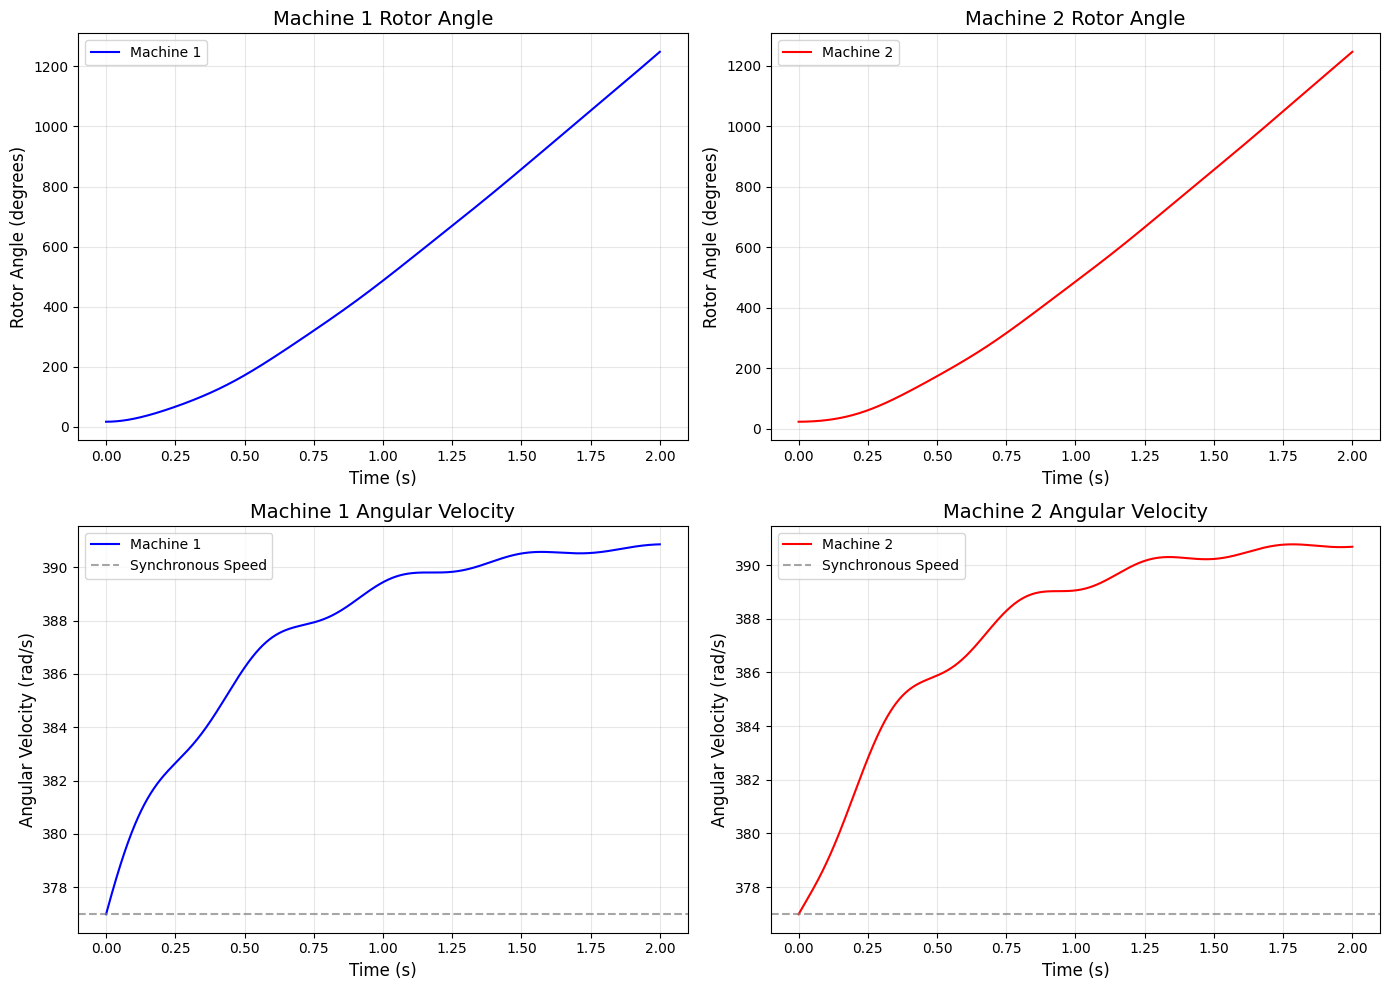

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot delta for Machine 1
axes[0, 0].plot(trajectory['t'], np.degrees(trajectory['delta1']), 'b-', linewidth=1.5, label='Machine 1')
axes[0, 0].set_xlabel('Time (s)', fontsize=12)
axes[0, 0].set_ylabel('Rotor Angle (degrees)', fontsize=12)
axes[0, 0].set_title('Machine 1 Rotor Angle', fontsize=14)
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()

# Plot delta for Machine 2
axes[0, 1].plot(trajectory['t'], np.degrees(trajectory['delta2']), 'r-', linewidth=1.5, label='Machine 2')
axes[0, 1].set_xlabel('Time (s)', fontsize=12)
axes[0, 1].set_ylabel('Rotor Angle (degrees)', fontsize=12)
axes[0, 1].set_title('Machine 2 Rotor Angle', fontsize=14)
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend()

# Plot omega for Machine 1
omega0 = 2 * np.pi * 60  # Synchronous speed
axes[1, 0].plot(trajectory['t'], trajectory['omega1'], 'b-', linewidth=1.5, label='Machine 1')
axes[1, 0].axhline(y=omega0, color='gray', linestyle='--', alpha=0.7, label='Synchronous Speed')
axes[1, 0].set_xlabel('Time (s)', fontsize=12)
axes[1, 0].set_ylabel('Angular Velocity (rad/s)', fontsize=12)
axes[1, 0].set_title('Machine 1 Angular Velocity', fontsize=14)
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend()

# Plot omega for Machine 2
axes[1, 1].plot(trajectory['t'], trajectory['omega2'], 'r-', linewidth=1.5, label='Machine 2')
axes[1, 1].axhline(y=omega0, color='gray', linestyle='--', alpha=0.7, label='Synchronous Speed')
axes[1, 1].set_xlabel('Time (s)', fontsize=12)
axes[1, 1].set_ylabel('Angular Velocity (rad/s)', fontsize=12)
axes[1, 1].set_title('Machine 2 Angular Velocity', fontsize=14)
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend()

plt.tight_layout()
plt.show()

## Combined View

Plot both machines on the same axes for comparison.

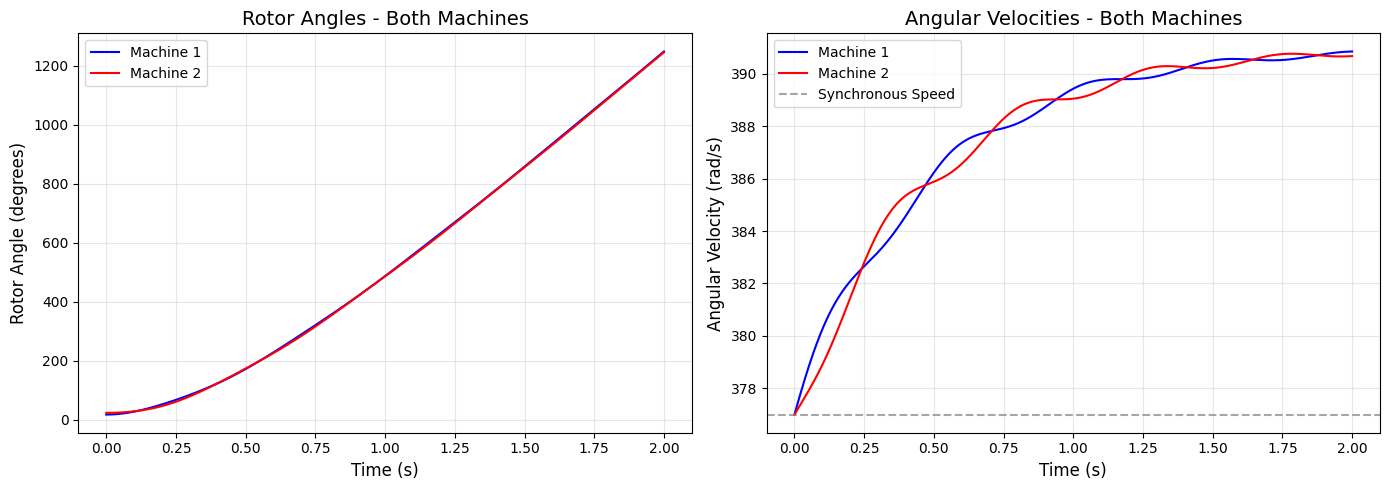

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Combined delta plot
axes[0].plot(trajectory['t'], np.degrees(trajectory['delta1']), 'b-', linewidth=1.5, label='Machine 1')
axes[0].plot(trajectory['t'], np.degrees(trajectory['delta2']), 'r-', linewidth=1.5, label='Machine 2')
axes[0].set_xlabel('Time (s)', fontsize=12)
axes[0].set_ylabel('Rotor Angle (degrees)', fontsize=12)
axes[0].set_title('Rotor Angles - Both Machines', fontsize=14)
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Combined omega plot
axes[1].plot(trajectory['t'], trajectory['omega1'], 'b-', linewidth=1.5, label='Machine 1')
axes[1].plot(trajectory['t'], trajectory['omega2'], 'r-', linewidth=1.5, label='Machine 2')
axes[1].axhline(y=omega0, color='gray', linestyle='--', alpha=0.7, label='Synchronous Speed')
axes[1].set_xlabel('Time (s)', fontsize=12)
axes[1].set_ylabel('Angular Velocity (rad/s)', fontsize=12)
axes[1].set_title('Angular Velocities - Both Machines', fontsize=14)
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

## Data Generator Test

Test the data generator for PINN training data preparation.

In [6]:
# Create data generator
data_gen = MultiMachineDataGenerator([m1, m2], B_matrix)

# Generate normalization parameters
t_scale, delta_means, delta_stds, omega_means, omega_stds = data_gen.compute_normalization_params(trajectory)

print("Normalization Parameters:")
print(f"  Time scale: {t_scale:.3f} s")
print(f"\n  Machine 1:")
print(f"    Delta mean: {delta_means[0]:.4f}, std: {delta_stds[0]:.4f}")
print(f"    Omega mean: {omega_means[0]:.4f}, std: {omega_stds[0]:.4f}")
print(f"\n  Machine 2:")
print(f"    Delta mean: {delta_means[1]:.4f}, std: {delta_stds[1]:.4f}")
print(f"    Omega mean: {omega_means[1]:.4f}, std: {omega_stds[1]:.4f}")

# Sample training data
batch = data_gen.sample_training_data(trajectory, n_collocation=100, n_data_points=20)
print(f"\nTraining Data Batch:")
print(f"  Collocation points: {batch['t_colloc'].shape}")
print(f"  Data points: {batch['t_data'].shape}")
print(f"  Initial condition points: {batch['t_ic'].shape}")

Normalization Parameters:
  Time scale: 2.000 s

  Machine 1:
    Delta mean: 9.2546, std: 6.6299
    Omega mean: 387.7341, std: 3.4731

  Machine 2:
    Delta mean: 9.2178, std: 6.6220
    Omega mean: 387.6609, std: 3.6500

Training Data Batch:
  Collocation points: torch.Size([100, 1])
  Data points: torch.Size([20, 1])
  Initial condition points: torch.Size([1, 1])
